# DATA PREPROCESSING AND FEATURE ENGINEERING IN MACHINE LEARNING  
**Objective:**  
This assignment aims to equip you with practical skills in data preprocessing, feature engineering, and feature selection techniques, which are crucial for building efficient machine learning models. You will work with a provided dataset to apply various techniques such as scaling, encoding, and feature selection methods including isolation forest and PPS score analysis.  
**Dataset:** 
Given "Adult" dataset, which predicts whether income exceeds $50K/yr based on census data.

## Tasks:  
**1. Handle missing values as per the best practices (imputation, removal, etc.).**  
● Apply scaling techniques to numerical features:  
a. Standard Scaling  
b. Min-Max Scaling   
●	Discuss the scenarios where each scaling technique is preferred and why.  

In [1]:
# Load the Dataset 
import pandas as pd 
df = pd.read_csv("adult_with_headers.csv")

In [2]:
# Head of the Data 
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
# Tail of the Data 
df.tail()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [4]:
# Shape of the Dataset 
df.shape

(32561, 15)

In [5]:
# Check column 
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [6]:
# General Information 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [7]:
# Statistica Summary 
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [8]:
# Check Missing Values
missing  = pd.DataFrame({
    "Missing" : df.isnull().sum(),
    "Percentage" : ( df.isnull().sum() / len(df) ) * 100
})

missing.sort_values('Percentage', ascending = False)

,Missing,Percentage
age,0,0.0
workclass,0,0.0
fnlwgt,0,0.0
education,0,0.0
education_num,0,0.0
marital_status,0,0.0
occupation,0,0.0
relationship,0,0.0
race,0,0.0
sex,0,0.0


In [9]:
# Check Duplicates values 
df.duplicated().sum()

np.int64(24)

In [10]:
# Drop Duplicates Values 
df.drop_duplicates(inplace = True)

In [11]:
# Verify 
df.duplicated().sum()

np.int64(0)

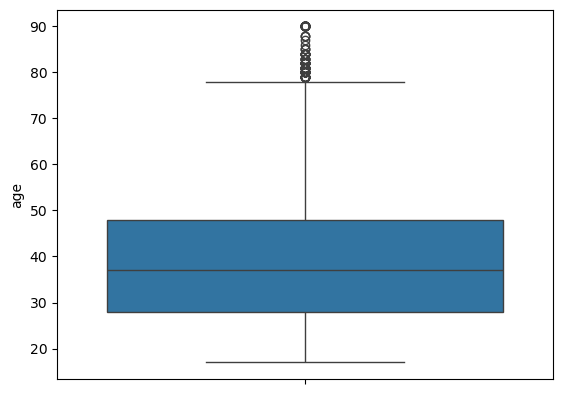

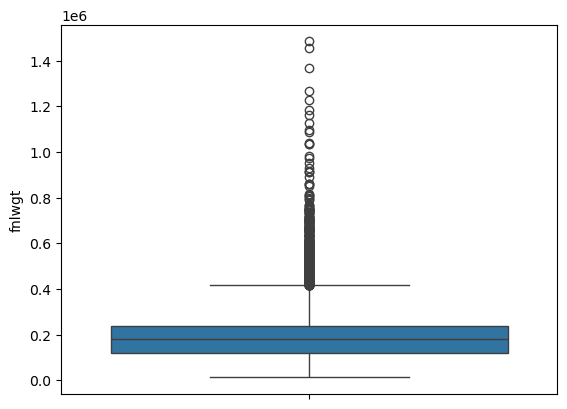

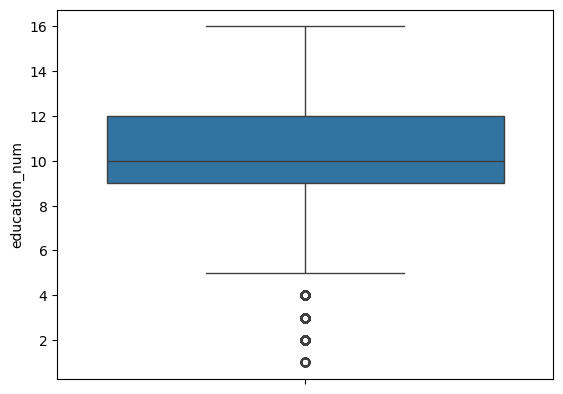

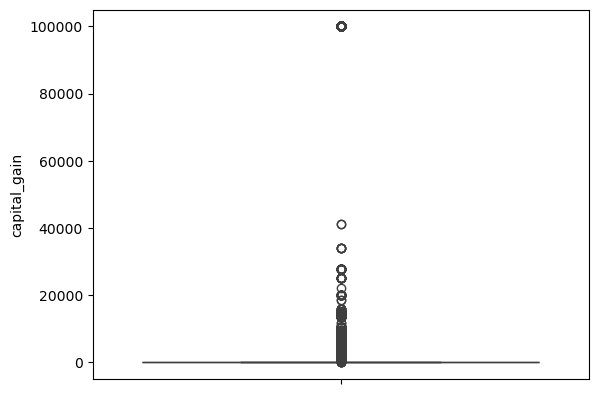

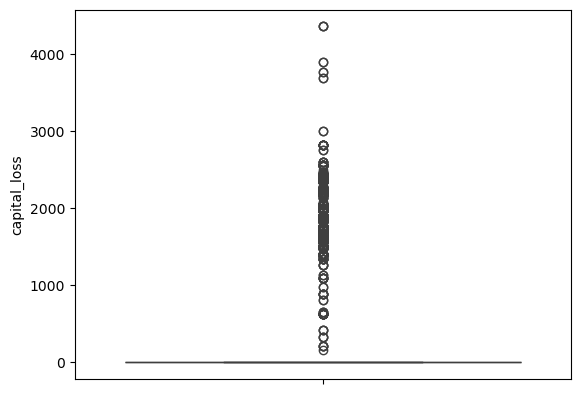

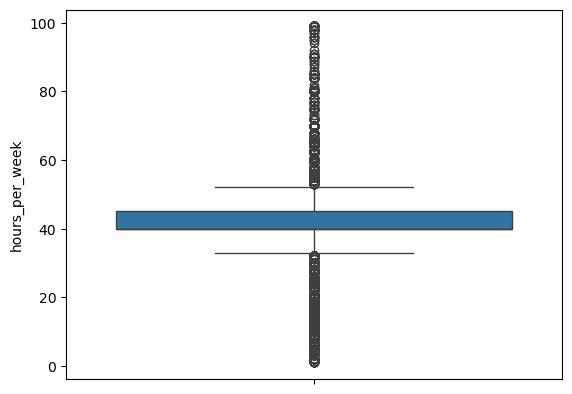

In [12]:
# Check Ouitlier
import matplotlib.pyplot as plt 
import seaborn as sns
for col in df.select_dtypes(include = ['int','float']).columns:
    sns.boxplot(df[col])
    plt.show()

In [13]:
# Ouitlier Capping 
for i in df.select_dtypes(include = ['int','float']).columns:
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)

    IQR = q3 - q1 
    lower_bound = q1 - 1.5*IQR 
    upper_bound = q3 + 1.5*IQR

    df[i] = df[i].clip(lower_bound, upper_bound)


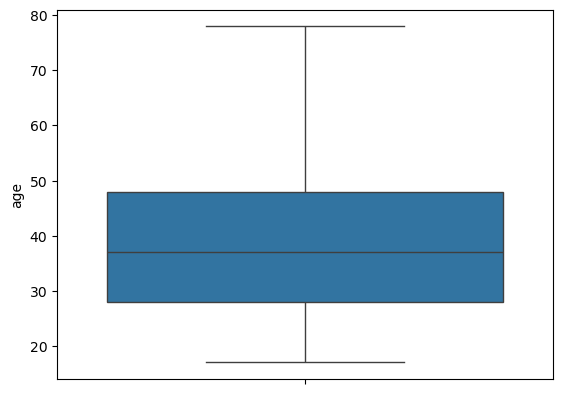

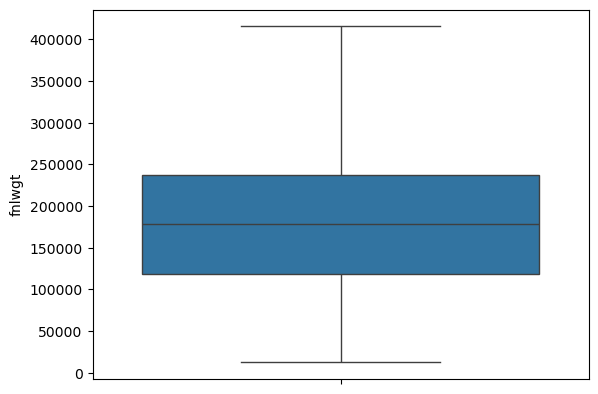

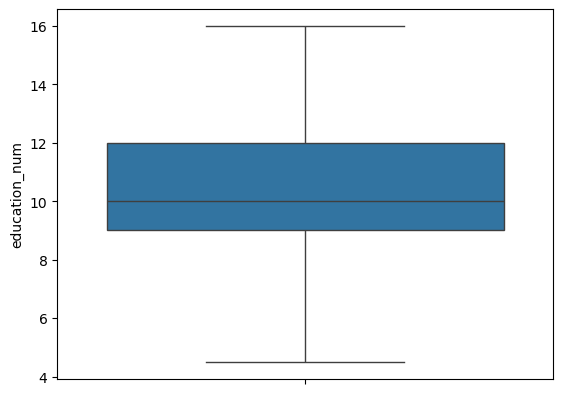

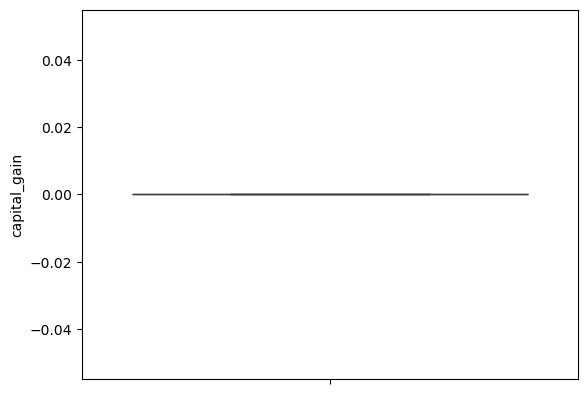

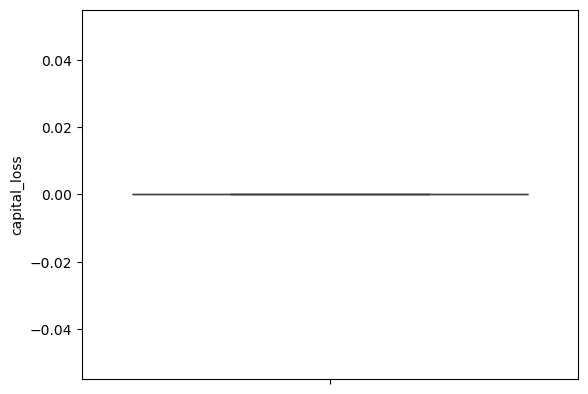

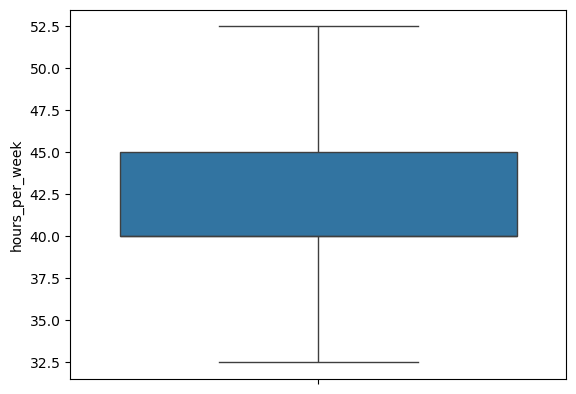

In [14]:
# Verify 
for col in df.select_dtypes(include = ['int','float']).columns:
    sns.boxplot(df[col])
    plt.show()

#### Scaling:

In [15]:
# Standard Scaler 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
for col in df.select_dtypes (include = ['int','float']).columns:
    df[[col]] = scaler.fit_transform(df[[col]])

In [16]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.032472,State-gov,-1.149209,Bachelors,1.168918,Never-married,Adm-clerical,Not-in-family,White,Male,0.0,0.0,-0.194472,United-States,<=50K
1,0.844002,Self-emp-not-inc,-1.088284,Bachelors,1.168918,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,-1.406640,United-States,<=50K
2,-0.041304,Private,0.303007,HS-grad,-0.457496,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,-0.194472,United-States,<=50K
3,1.065329,Private,0.503550,11th,-1.270703,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,-0.194472,United-States,<=50K
4,-0.779058,Private,1.593665,Bachelors,1.168918,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,-0.194472,Cuba,<=50K


In [17]:
# MIN_MAX Scaling 
from sklearn.preprocessing import MinMaxScaler
mm_scaler = MinMaxScaler()
for col in df.select_dtypes(include = ['int','float']).columns:
    df[[col]] = mm_scaler.fit_transform(df[[col]])

In [18]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.360656,State-gov,0.161680,Bachelors,0.739130,Never-married,Adm-clerical,Not-in-family,White,Male,0.0,0.0,0.375,United-States,<=50K
1,0.540984,Self-emp-not-inc,0.176044,Bachelors,0.739130,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,0.000,United-States,<=50K
2,0.344262,Private,0.504046,HS-grad,0.391304,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,0.375,United-States,<=50K
3,0.590164,Private,0.551325,11th,0.217391,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,0.375,United-States,<=50K
4,0.180328,Private,0.808324,Bachelors,0.739130,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,0.375,Cuba,<=50K


**● Discuss the scenarios where each scaling technique is preferred and why.**  
The two most common feature scaling techniques are Normalization (Min-Max Scaling) and Standardization (Z-score Scaling). The choice depends on the machine learning algorithm and the nature of the data. 

**1. When to Use Normalization**
Normalization is preferred when:   
Features have very different ranges.  
The algorithm relies on distance calculations.  
The data does not necessarily follow a normal distribution.  
A fixed range (0–1) is beneficial.   

Common Algorithms: 
K-Nearest Neighbors (KNN)  
K-Means Clustering  
Neural Networks  
Deep Learning models  

**2. When to Use Standardization**   
Standardization is preferred when:  
Features have different scales.  
Data is approximately normally distributed.  
The algorithm assumes centered data or uses gradient optimization.  
Feature values may contain negative numbers.  

Common Algorithms :  
Linear Regression  
Logistic Regression  
Support Vector Machine (SVM)  
Principal Component Analysis (PCA)  
Neural Networks  

## 2. Encoding Techniques:  

#### ● Apply One-Hot Encoding to categorical variables with less than 5 categories.  

In [19]:
# Create a variable to store categorical columns having less than 5 categories

categorical_cols = df.select_dtypes(include=['object', 'category']).columns

cols_less_than_5 = []

for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} categories")
    
    if df[col].nunique() < 5:
        cols_less_than_5.append(col)

print("Less than 5 category:", cols_less_than_5)

workclass: 9 categories
education: 16 categories
marital_status: 7 categories
occupation: 15 categories
relationship: 6 categories
race: 5 categories
sex: 2 categories
native_country: 42 categories
income: 2 categories
Less than 5 category: ['sex', 'income']


In [20]:
# Check unique value which have less than 5 categories
print(df['race'].unique())
print(df['sex'].unique())
print(df['income'].unique())

[' White' ' Black' ' Asian-Pac-Islander' ' Amer-Indian-Eskimo' ' Other']
[' Male' ' Female']
[' <=50K' ' >50K']


In [21]:
# Remove extra leading or trailing spaces 
cat_cols = df.select_dtypes(include = 'object').columns
for col in cat_cols:
    df[col].str.strip()

In [22]:
# Encoding (ONE HOT ENCODING)
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Create the encoder
ohe = OneHotEncoder(sparse_output=False)

# Apply One-Hot Encoding
encoded = ohe.fit_transform(df[cols_less_than_5])

# Create a DataFrame with the encoded columns
encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(cols_less_than_5),
    index=df.index
)

# Drop original columns and concatenate encoded columns
df = pd.concat([df.drop(columns=cols_less_than_5), encoded_df], axis=1)

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Female,sex_ Male,income_ <=50K,income_ >50K
0,0.360656,State-gov,0.161680,Bachelors,0.739130,Never-married,Adm-clerical,Not-in-family,White,0.0,0.0,0.375,United-States,0.0,1.0,1.0,0.0
1,0.540984,Self-emp-not-inc,0.176044,Bachelors,0.739130,Married-civ-spouse,Exec-managerial,Husband,White,0.0,0.0,0.000,United-States,0.0,1.0,1.0,0.0
2,0.344262,Private,0.504046,HS-grad,0.391304,Divorced,Handlers-cleaners,Not-in-family,White,0.0,0.0,0.375,United-States,0.0,1.0,1.0,0.0
3,0.590164,Private,0.551325,11th,0.217391,Married-civ-spouse,Handlers-cleaners,Husband,Black,0.0,0.0,0.375,United-States,0.0,1.0,1.0,0.0
4,0.180328,Private,0.808324,Bachelors,0.739130,Married-civ-spouse,Prof-specialty,Wife,Black,0.0,0.0,0.375,Cuba,1.0,0.0,1.0,0.0


#### Use Label Encoding for categorical variables. Data Exploration and Preprocessing:  

In [23]:
# Create a variable to store categorical columns having greater than 5 categories

categorical_cols = df.select_dtypes(include=['object', 'category']).columns

cols_greater_than_5 = []

for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} categories")
    
    if df[col].nunique() > 5:
        cols_greater_than_5.append(col)

print("Greater than 5 category:", cols_greater_than_5)

workclass: 9 categories
education: 16 categories
marital_status: 7 categories
occupation: 15 categories
relationship: 6 categories
race: 5 categories
native_country: 42 categories
Greater than 5 category: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'native_country']


In [24]:
# Label Encoding for remaining columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in cols_greater_than_5:
    df[col] = le.fit_transform(df[col])
# df[[cols_greater_than_5]] = le.fit_transform(df[[cols_greater_than_5]])

In [25]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Female,sex_ Male,income_ <=50K,income_ >50K
0,0.360656,7,0.161680,9,0.739130,4,1,1,White,0.0,0.0,0.375,39,0.0,1.0,1.0,0.0
1,0.540984,6,0.176044,9,0.739130,2,4,0,White,0.0,0.0,0.000,39,0.0,1.0,1.0,0.0
2,0.344262,4,0.504046,11,0.391304,0,6,1,White,0.0,0.0,0.375,39,0.0,1.0,1.0,0.0
3,0.590164,4,0.551325,1,0.217391,2,6,0,Black,0.0,0.0,0.375,39,0.0,1.0,1.0,0.0
4,0.180328,4,0.808324,9,0.739130,2,10,5,Black,0.0,0.0,0.375,5,1.0,0.0,1.0,0.0


#### ●	Load the dataset and conduct basic data exploration (summary statistics, missing values, data types). 

In [26]:
# Load the Dataset 
df1 = pd.read_csv("adult_with_headers.csv")

In [27]:
# Head of the data 
df1.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [28]:
# Tail of the data 
df1.tail()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [29]:
# Shape of the dataset 
df1.shape

(32561, 15)

In [30]:
# General Information 
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [31]:
# Statistical Summary 
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32537.0,0.353440,0.222211,0.0,0.180328,0.327869,0.508197,1.0
workclass,32537.0,3.868734,1.456445,0.0,4.000000,4.000000,4.000000,8.0
fnlwgt,32537.0,0.432611,0.235758,0.0,0.261594,0.411620,0.556957,1.0
education,32537.0,10.297507,3.870142,0.0,9.000000,11.000000,12.000000,15.0
education_num,32537.0,0.489145,0.213864,0.0,0.391304,0.478261,0.652174,1.0
marital_status,32537.0,2.611427,1.506301,0.0,2.000000,2.000000,4.000000,6.0
occupation,32537.0,6.572856,4.229521,0.0,3.000000,7.000000,10.000000,14.0
relationship,32537.0,1.446538,1.607064,0.0,0.000000,1.000000,3.000000,5.0
capital_gain,32537.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0
capital_loss,32537.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0


In [32]:
# Check Missing Values
missing = pd.DataFrame({
    "Missing" : df1.isnull().sum(),
    "Percentage" : (df1.isnull().sum() /len(df) ) * 100
}) 

missing.sort_values('Percentage', ascending = False )

,Missing,Percentage
age,0,0.0
workclass,0,0.0
fnlwgt,0,0.0
education,0,0.0
education_num,0,0.0
marital_status,0,0.0
occupation,0,0.0
relationship,0,0.0
race,0,0.0
sex,0,0.0


In [33]:
# Check Duplicates values 
df1.duplicated().sum()

np.int64(24)

In [34]:
# Drop Duplicates Values 
df1.drop_duplicates(inplace = True)

 #### ●	Discuss the pros and cons of One-Hot Encoding and Label Encoding.    
**Pros of One-Hot Encoding:**  
Does not introduce any ordinal relationship between categories.  
Suitable for nominal categorical variables (e.g., Gender, Color, City).   
Improves the performance of algorithms such as Linear Regression, Logistic Regression, and KNN.  
Easy to understand and interpret.  
**Cons of One-Hot Encoding:**    
Increases the number of columns (high dimensionality).   
Can consume more memory and increase computation time.  
Not suitable for columns with many unique categories (e.g., thousands of cities).  
May lead to the dummy variable trap if all dummy variables are retained in regression models (can be avoided with drop='first').

**Pros of Label Encoding:**  
Simple and fast to implement.  
Does not increase the number of features.  
Memory efficient.  
Suitable for ordinal categorical variables (e.g., Low, Medium, High).  
Works well with tree-based models such as Decision Trees, Random Forests, and XGBoost.  
**Cons of Label Encoding:**  
Introduces an artificial order among categories.   
Algorithms may incorrectly assume that larger numbers represent higher importance.  
Can reduce the performance of distance-based and linear models when used on nominal data.   

## 4. Feature Engineering:  
● Create at least 2 new features that could be beneficial for the model. Explain the rationale behind your choices.

In [35]:
## Feature 1: Net Capital

# People can have both capital gain and capital loss. 
# Combining them into one feature gives the model a better measure of overall capital income.

df["net_capital"] = df["capital_gain"] - df["capital_loss"]

In [36]:
#Feature 2: Total Work Experience Group (Age Group)


#Instead of using the exact age, create age groups.
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 30, 50, 100],
    labels=["Young", "Middle", "Senior"]
)

#### ● Apply a transformation (e.g., log transformation) to at least one skewed numerical feature and justify your choice.  

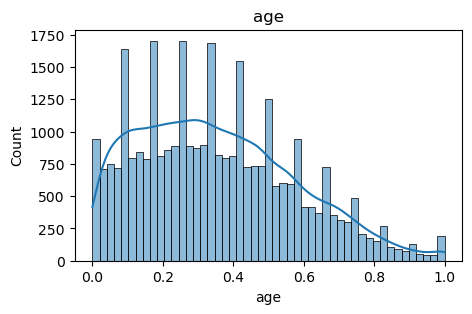

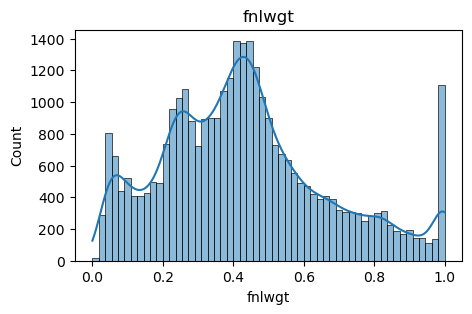

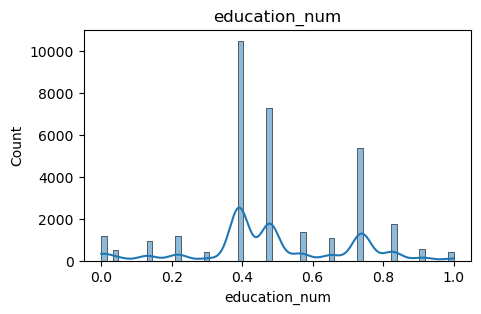

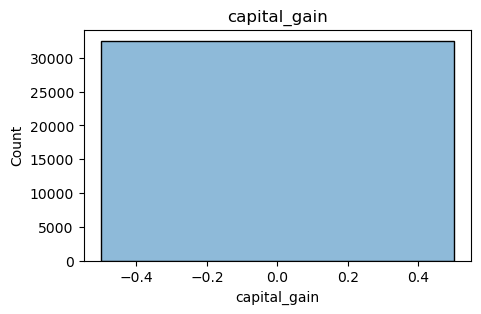

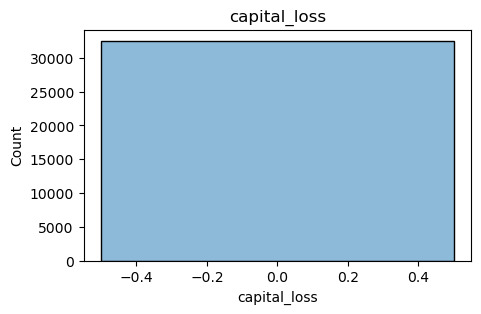

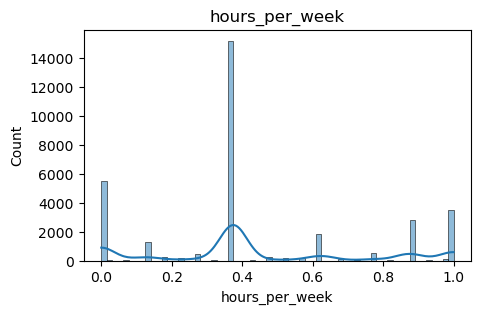

In [37]:
# To find skewed feature:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df1.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [38]:
# To check skewness in mathmetical form
skewness = df[numerical_cols].skew().sort_values(ascending=False)
print(skewness)

fnlwgt            0.548158
age               0.513435
hours_per_week    0.438212
capital_gain      0.000000
capital_loss      0.000000
education_num    -0.033530
dtype: float64


In [39]:
# Apply log1p
import numpy as np

df["fnlwgt_log"] = np.log1p(df["fnlwgt"])
# np.log() cannot handle values equal to 0.
# np.log1p(x) computes log(1 + x), so it safely handles zero values.

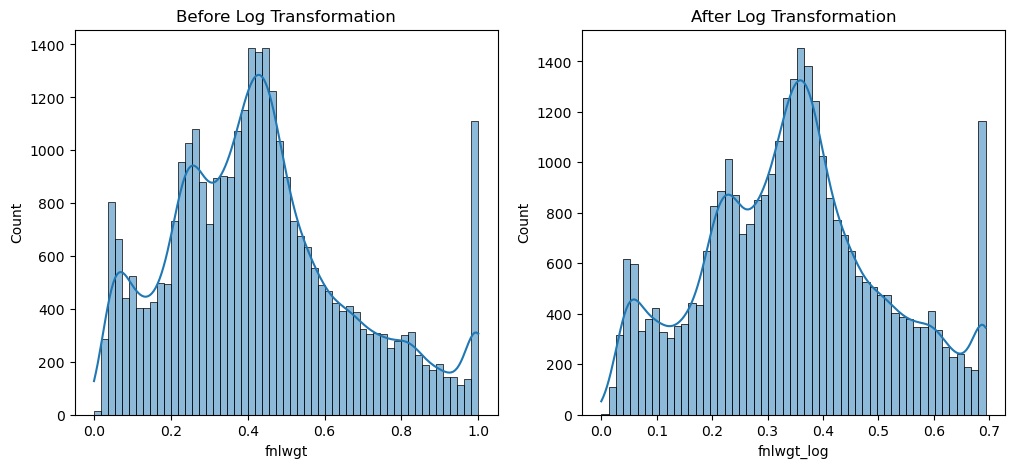

In [40]:
# Visualization 
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["fnlwgt"], kde=True)
plt.title("Before Log Transformation")

plt.subplot(1,2,2)
sns.histplot(df["fnlwgt_log"], kde=True)
plt.title("After Log Transformation")

plt.show()

**Justification:**  

The capital_gain feature is highly positively skewed, with most observations having values close to zero and a few very large values. A log transformation was applied using np.log1p() to reduce the skewness, compress the effect of extreme values, and produce a more balanced distribution. This transformation can improve the performance of machine learning models by making the feature easier to model.